# Baseline Model: Linear Regression

This notebook implements the project baseline model for **national electricity demand forecasting** using:
- lagged demand features (autoregressive signal)
- socio-economic features (`gdp`, `population`, `gdp_per_capita`)

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 2003-2019, Test = 2020-2023  
**Metrics:** RMSE and MAE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load dataset
DATA_PATH = 'df_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: df_clean.csv
Shape: 4290 rows x 18 columns
Countries: 113
Year range: 1985-2024


,country,year,population,iso_code,gdp,biofuel_electricity,coal_electricity,electricity_demand,electricity_generation,fossil_electricity,gas_electricity,greenhouse_gas_emissions,hydro_electricity,nuclear_electricity,oil_electricity,renewables_electricity,solar_electricity,wind_electricity
0,American Samoa,1985,39128.0,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,American Samoa,1986,40588.0,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,American Samoa,1987,42095.0,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,American Samoa,1988,43634.0,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,American Samoa,1989,45207.0,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Feature engineering
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

# Lagged year-over-year change (no leakage): (t-1) - (t-2)
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)

# Exogenous interaction
df['gdp_per_capita'] = df['gdp'] / df['population']

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
df_model[['country', 'year'] + FEATURE_COLS + [TARGET]].head()

Usable rows after lag features: 1525


,country,year,demand_lag1,demand_lag2,demand_lag3,demand_yoy_change,gdp,population,gdp_per_capita,electricity_demand
89,Armenia,2003,4.96,5.37,5.32,-0.41,1.992877e+10,3038976.0,6557.726539,5.02
90,Armenia,2004,5.02,4.96,5.37,0.06,2.135096e+10,3022544.0,7063.903536,5.04
91,Armenia,2005,5.04,5.02,4.96,0.02,2.362654e+10,3006360.0,7858.852082,5.30
92,Armenia,2006,5.30,5.04,5.02,0.26,2.593783e+10,2990371.0,8673.784713,5.40
93,Armenia,2007,5.40,5.30,5.04,0.10,2.861037e+10,2974825.0,9617.495414,5.77


In [4]:
# Temporal train/test split
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows: {len(test)}')
print(f'Features: {FEATURE_COLS}')

Train rows: 1315
Test rows: 210
Features: ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [5]:
# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [6]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 2.235 TWh | Train MAE: 0.652 TWh
Test RMSE : 4.393 TWh | Test MAE : 1.215 TWh


In [7]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
53,Russia,3,34.331,31.931
34,Lebanon,3,7.383,7.045
20,Finland,3,5.224,4.989
68,Uzbekistan,3,4.949,4.760
29,Kazakhstan,3,4.765,4.135
...,...,...,...,...
7,Cape Verde,3,0.043,0.042
15,Dominica,3,0.042,0.042
56,Sao Tome and Principe,3,0.041,0.039
14,Djibouti,3,0.031,0.030


In [8]:
# Coefficients (interpretability)
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: 0.0202


,feature,coefficient
0,demand_lag1,6.048003e-01
1,demand_lag2,4.202280e-01
3,demand_yoy_change,1.845723e-01
2,demand_lag3,1.288003e-02
6,gdp_per_capita,2.727931e-06
5,population,2.686716e-08
4,gdp,-8.463961e-12


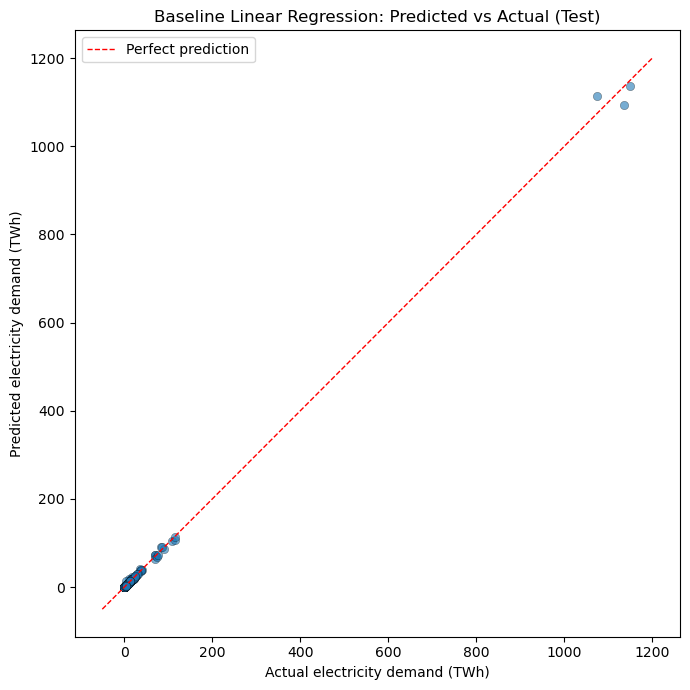

In [9]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

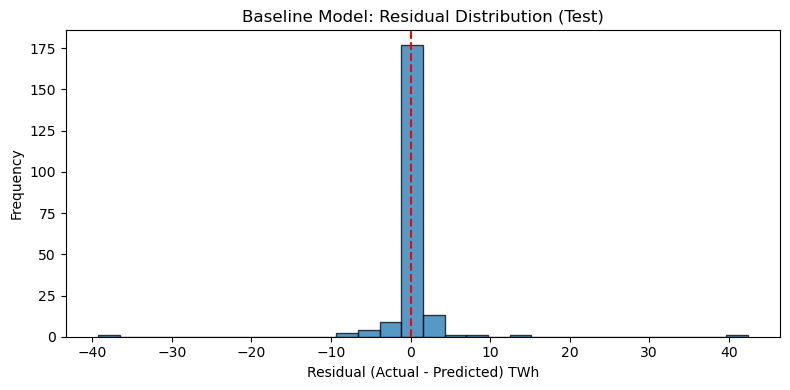

In [10]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

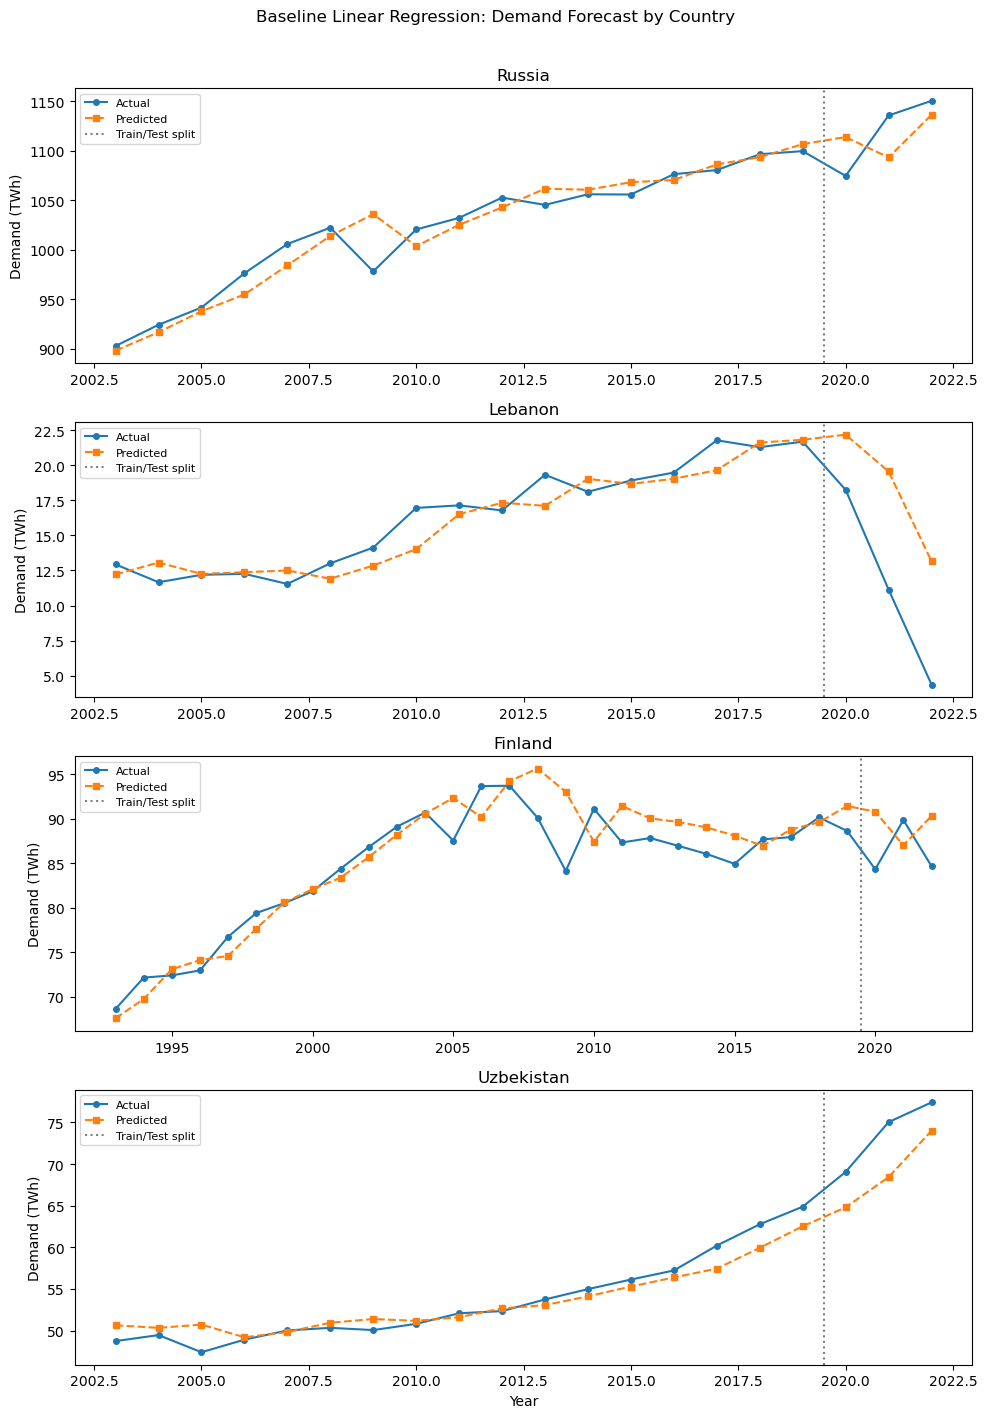

In [12]:
# Plot 3: Country-level overlays
preferred_countries = ['United States', 'India', 'Germany', 'Brazil']
available_countries = df_model['country'].unique()
sample_countries = [c for c in preferred_countries if c in available_countries]

# Fall back to top-4 countries by test RMSE if none of the defaults are present
if not sample_countries:
    sample_countries = country_metrics['country'].head(4).tolist()

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    cdf['predicted'] = model.predict(cdf[FEATURE_COLS])

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Baseline Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()


In [15]:
# Table of actual vs predicted for for all countries in test set
results_df = test[['country', 'year', TARGET]].copy()
results_df['predicted'] = y_pred_test
results_df.head(30)

,country,year,electricity_demand,predicted
106,Armenia,2020,6.630000,6.538010
107,Armenia,2021,7.090000,6.684110
108,Armenia,2022,8.430000,7.042163
184,Azerbaijan,2020,24.740000,24.321828
185,Azerbaijan,2021,26.270000,24.554414
186,Azerbaijan,2022,26.080000,25.742728
263,Belarus,2020,38.040001,38.320633
264,Belarus,2021,40.950001,38.261745
265,Belarus,2022,36.480000,40.611320
342,Benin,2020,1.630000,1.783846


## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It should be compared directly against SARIMAX (same split and metrics).
- If SARIMAX cannot beat this baseline on Test RMSE/MAE, revisit feature engineering or SARIMAX specification.